## PART 1

[*********************100%***********************]  10 of 10 completed


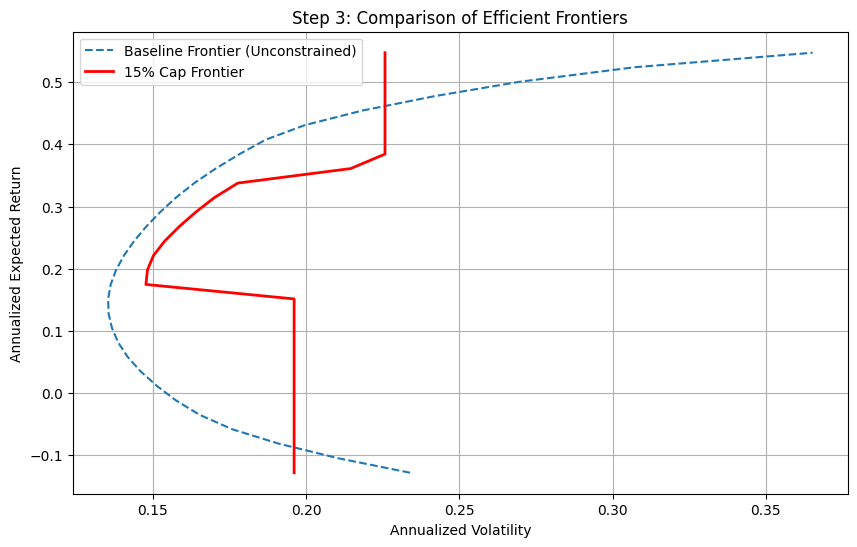

------------------------------
Step 1 Weights (Unconstrained):
TSLA: 0.00%
WMT: 0.00%
BAC: 0.00%
GS: 28.31%
LLY: 7.24%
MRK: 19.58%
GOOG: 0.00%
META: 0.00%
AAPL: 44.87%
XOM: 0.00%

Step 2 Weights (15% Cap):
TSLA: 0.00%
WMT: 15.00%
BAC: 15.00%
GS: 15.00%
LLY: 15.00%
MRK: 15.00%
GOOG: 0.00%
META: 0.00%
AAPL: 15.00%
XOM: 10.00%
------------------------------
Step 1 OOS Cumulative Return: 7.00%
Step 2 OOS Cumulative Return: 10.27%


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


tickers = ['TSLA', 'WMT', 'BAC', 'GS', 'LLY', 'MRK', 'GOOG', 'META', 'AAPL', 'XOM']
start_date = '2023-07-01'
end_date = '2025-06-30'
oos_start = '2025-07-01'
oos_end = '2025-09-30'


df = yf.download(tickers, start=start_date, end=oos_end, auto_adjust=True)


if 'Close' in df.columns:
    data = df['Close']
else:
    data = df

train_data = data.loc[start_date:end_date]
oos_data = data.loc[oos_start:oos_end]


returns = train_data.pct_change().dropna()
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252


def portfolio_performance(weights, mean_returns, cov_matrix):
    p_ret = np.dot(weights, mean_returns)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return p_std, p_ret

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.04):
    p_std, p_ret = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_std

def solve_optimal_weights(mean_returns, cov_matrix, max_weight=1.0):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, max_weight) for _ in range(num_assets))


    init_guess = num_assets * [1./num_assets]

    result = minimize(neg_sharpe_ratio, init_guess,
                      args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x


weights_step1 = solve_optimal_weights(mean_returns, cov_matrix, max_weight=1.0)


weights_step2 = solve_optimal_weights(mean_returns, cov_matrix, max_weight=0.15)


def get_frontier(mean_returns, cov_matrix, max_weight):
    # Create a range of target returns between the minimum and maximum mean returns
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 30)
    frontier_volatility = []

    for target in target_returns:
        cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - target})
        bounds = tuple((0, max_weight) for _ in range(len(mean_returns)))
        res = minimize(lambda x: np.sqrt(np.dot(x.T, np.dot(cov_matrix, x))),
                       len(mean_returns) * [1./len(mean_returns)],
                       method='SLSQP', bounds=bounds, constraints=cons)
        frontier_volatility.append(res.fun)
    return frontier_volatility, target_returns

vol1, ret1 = get_frontier(mean_returns, cov_matrix, 1.0)
vol2, ret2 = get_frontier(mean_returns, cov_matrix, 0.15)

plt.figure(figsize=(10,6))
plt.plot(vol1, ret1, label='Baseline Frontier (Unconstrained)', linestyle='--')
plt.plot(vol2, ret2, label='15% Cap Frontier', color='red', linewidth=2)
plt.title('Step 3: Comparison of Efficient Frontiers')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Expected Return')
plt.grid(True)
plt.legend()
plt.show()

oos_returns = oos_data.pct_change().dropna()
port1_daily_rets = (oos_returns * weights_step1).sum(axis=1)
port2_daily_rets = (oos_returns * weights_step2).sum(axis=1)

print("-" * 30)
print("Step 1 Weights (Unconstrained):")
for t, w in zip(tickers, weights_step1):
    print(f"{t}: {w:.2%}")

print("\nStep 2 Weights (15% Cap):")
for t, w in zip(tickers, weights_step2):
    print(f"{t}: {w:.2%}")

print("-" * 30)
print(f"Step 1 OOS Cumulative Return: {((1 + port1_daily_rets).prod() - 1):.2%}")
print(f"Step 2 OOS Cumulative Return: {((1 + port2_daily_rets).prod() - 1):.2%}")

**PART 2**

**Install Required Libraries**

In [ ]:
!pip install yfinance pandas numpy cvxpy statsmodels matplotlib seaborn pandas_datareader

**1. Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as web

**2. Download Stock Price Data (July 2023 – June 2025)**

In [ ]:
tickers = ['TSLA','WMT','BAC','GS','LLY','MRK','GOOG','META','AAPL','XOM']

start_date = "2023-07-01"
end_date = "2025-06-30"

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

returns = prices.pct_change().dropna()
returns.head()

[*********************100%***********************]  10 of 10 completed


Price          Close                                                    \
Ticker          AAPL       BAC      GOOG        GS       LLY      META   
Date                                                                     
2023-07-05 -0.005871 -0.004110  0.017170 -0.020085  0.009276  0.029194   
2023-07-06  0.002509 -0.027510 -0.013863 -0.022028 -0.005347 -0.008085   
2023-07-07 -0.005891  0.008840 -0.006533  0.006933 -0.024028 -0.005000   
2023-07-10 -0.010856  0.004557 -0.027218  0.004125  0.002389  0.012288   
2023-07-11 -0.002810  0.012561  0.007187  0.013935 -0.030387  0.014247   

Price                                               ...    Volume            \
Ticker           MRK      TSLA       WMT       XOM  ...      AAPL       BAC   
Date                                                ...                       
2023-07-05 -0.005510  0.009506 -0.000569 -0.005118  ...  0.491513  0.209583   
2023-07-06 -0.017151 -0.021028 -0.006325 -0.037321  ... -0.038917  0.389576   
2023-07-07 -0.024608 -0.007630 -0.023041  0.002332  ...  0.038158 -0.341856   
2023-07-10  0.008807 -0.017564  0.009056  0.014831  ...  0.279979  0.052438   
2023-07-11 -0.011459  0.000668 -0.001485  0.012227  ... -0.221689  0.135584   

Price                                                                   \
Ticker          GOOG        GS       LLY      META       MRK      TSLA   
Date                                                                     
2023-07-05  0.283836  1.313878  0.008045  2.924478  1.067840  0.098967   
2023-07-06 -0.005485  0.131160  0.028871  0.405575  0.238147 -0.085142   
2023-07-07  0.184136  0.002140  0.329881 -0.462485  0.559319 -0.053626   
2023-07-10  0.569700 -0.388309 -0.309912  0.448382 -0.474294  0.048702   
2023-07-11 -0.445190  0.149735  0.775331 -0.255608  0.022726 -0.229876   

Price                           
Ticker           WMT       XOM  
Date                            
2023-07-05  1.033582  0.688685  
2023-07-06 -0.179604  0.437924  
2023-07-07  0.370680  0.220907  
2023-07-10 -0.344226 -0.321562  
2023-07-11 -0.116203 -0.154669  

[5 rows x 50 columns]

**3. Compute Expected Returns & Covariance Matrix**

In [ ]:
mu = returns.mean()
Sigma = returns.cov()

mu, Sigma

(Price   Ticker
 Close   AAPL      0.000257
         BAC       0.001206
         GOOG      0.000974
         GS        0.001767
         LLY       0.001310
         META      0.002164
         MRK      -0.000510
         TSLA      0.001081
         WMT       0.001365
         XOM       0.000275
 High    AAPL      0.000227
         BAC       0.001203
         GOOG      0.000947
         GS        0.001732
         LLY       0.001341
         META      0.002128
         MRK      -0.000530
         TSLA      0.000879
         WMT       0.001353
         XOM       0.000252
 Low     AAPL      0.000242
         BAC       0.001230
         GOOG      0.000915
         GS        0.001755
         LLY       0.001330
         META      0.002129
         MRK      -0.000529
         TSLA      0.000934
         WMT       0.001356
         XOM       0.000247
 Open    AAPL      0.000278
         BAC       0.001260
         GOOG      0.000951
         GS        0.001801
         LLY       0.001360
    

**4. Mean–Variance Optimization (Max Weight = 15%)**

In [ ]:
close_returns = returns["Close"]

In [ ]:
mu_close = close_returns.mean()
Sigma_close = close_returns.cov()

In [ ]:
import cvxpy as cp
import pandas as pd

n = len(mu_close)
w = cp.Variable(n)

objective = cp.Minimize(cp.quad_form(w, Sigma_close))

constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.15
]

problem = cp.Problem(objective, constraints)
problem.solve()

optimal_weights = pd.Series(w.value, index=mu_close.index)

optimal_weights.sort_values(ascending=False)

,0
Ticker,
BAC,1.500000e-01
GOOG,1.500000e-01
WMT,1.500000e-01
XOM,1.500000e-01
MRK,1.500000e-01
AAPL,1.193168e-01
LLY,1.186119e-01
GS,1.123714e-02
META,8.341653e-04


**5. Compute Portfolio Returns**

In [ ]:
close_returns = returns["Close"]

In [ ]:
close_returns = close_returns[optimal_weights.index]

In [ ]:
portfolio_returns = close_returns.dot(optimal_weights)
portfolio_returns.head()

print(close_returns.columns.tolist())
print(optimal_weights.index.tolist())

['AAPL', 'BAC', 'GOOG', 'GS', 'LLY', 'META', 'MRK', 'TSLA', 'WMT', 'XOM']
['AAPL', 'BAC', 'GOOG', 'GS', 'LLY', 'META', 'MRK', 'TSLA', 'WMT', 'XOM']


**6. Download Fama–French 5-Factor Data**

In [ ]:
ff_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily',
                            'famafrench', start=start_date)[0]

ff_factors.index = pd.to_datetime(ff_factors.index)

ff_factors = ff_factors / 100
ff_factors.head()

/tmp/ipython-input-825446906.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily',


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2023-07-03,0.0015,0.0027,0.0106,0.0018,0.0011,0.0002
2023-07-05,-0.0029,-0.0106,-0.0026,-0.0030,-0.0001,0.0002
2023-07-06,-0.0094,-0.0058,-0.0069,0.0057,0.0005,0.0002
2023-07-07,-0.0013,0.0130,0.0121,-0.0023,0.0018,0.0002
2023-07-10,0.0036,0.0124,-0.0001,-0.0103,0.0054,0.0002


**7. Align Portfolio & Factor Data**

In [ ]:
data = pd.concat([portfolio_returns, ff_factors], axis=1).dropna()

data.columns = ['Portfolio'] + list(ff_factors.columns)

data.head()

,Portfolio,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,,
2023-07-05,0.000478,-0.0029,-0.0106,-0.0026,-0.0030,-0.0001,0.0002
2023-07-06,-0.015915,-0.0094,-0.0058,-0.0069,0.0057,0.0005,0.0002
2023-07-07,-0.009931,-0.0013,0.0130,0.0121,-0.0023,0.0018,0.0002
2023-07-10,0.000550,0.0036,0.0124,-0.0001,-0.0103,0.0054,0.0002
2023-07-11,-0.000916,0.0076,0.0018,0.0048,-0.0021,0.0028,0.0002


**8. Compute Excess Portfolio Returns**

In [ ]:
data['Excess_Portfolio'] = data['Portfolio'] - data['RF']

**9. OLS Regression (Fama–French 5-Factor Model)**

In [ ]:
X = data[['Mkt-RF','SMB','HML','RMW','CMA']]
X = sm.add_constant(X)
Y = data['Excess_Portfolio']

ols_model = sm.OLS(Y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Excess_Portfolio   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     238.5
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          5.71e-129
Time:                        16:40:44   Log-Likelihood:                 1929.1
No. Observations:                 498   AIC:                            -3846.
Df Residuals:                     492   BIC:                            -3821.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.88e-05      0.000     -0.082      0.9

**10. Robust Regression (HC3 Standard Errors)**

In [ ]:
robust_model = sm.OLS(Y, X).fit(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Excess_Portfolio   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     125.5
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           1.80e-85
Time:                        16:40:48   Log-Likelihood:                 1929.1
No. Observations:                 498   AIC:                            -3846.
Df Residuals:                     492   BIC:                            -3821.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.88e-05      0.000     -0.081      0.9

**11. Training / Testing Split (Time-Series Safe)**

In [ ]:
split_date = "2025-01-01"

train = data.loc[:split_date]
test = data.loc[split_date:]

X_train = sm.add_constant(train[['Mkt-RF','SMB','HML','RMW','CMA']])
Y_train = train['Excess_Portfolio']

X_test = sm.add_constant(test[['Mkt-RF','SMB','HML','RMW','CMA']])
Y_test = test['Excess_Portfolio']

train_model = sm.OLS(Y_train, X_train).fit()

predictions = train_model.predict(X_test)

**12. Out-of-Sample Performance Metrics**

In [ ]:
rmse = np.sqrt(((Y_test - predictions)**2).mean())
r2_out = 1 - ((Y_test - predictions)**2).sum() / ((Y_test - Y_test.mean())**2).sum()

rmse, r2_out

(np.float64(0.006758878938928171), np.float64(0.7767238003005621))

**13. Correlation Matrix of Fama–French Factors**

In [ ]:
corr_matrix = ff_factors[['Mkt-RF','SMB','HML','RMW','CMA']].corr()
corr_matrix

,Mkt-RF,SMB,HML,RMW,CMA
Mkt-RF,1.000000,0.216287,-0.257876,-0.408714,-0.048203
SMB,0.216287,1.000000,0.378243,-0.400338,0.175107
HML,-0.257876,0.378243,1.000000,0.209535,0.202981
RMW,-0.408714,-0.400338,0.209535,1.000000,-0.019523
CMA,-0.048203,0.175107,0.202981,-0.019523,1.000000


**14. Heatmap Visualization**

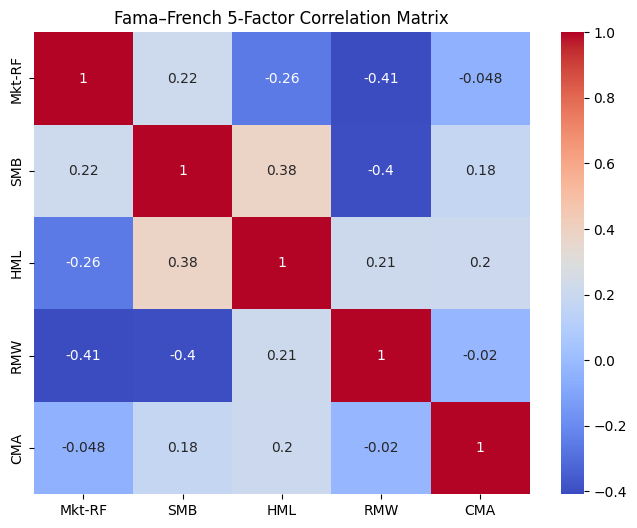

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Fama–French 5-Factor Correlation Matrix")
plt.show()

**15. Plot Actual vs Predicted Returns**

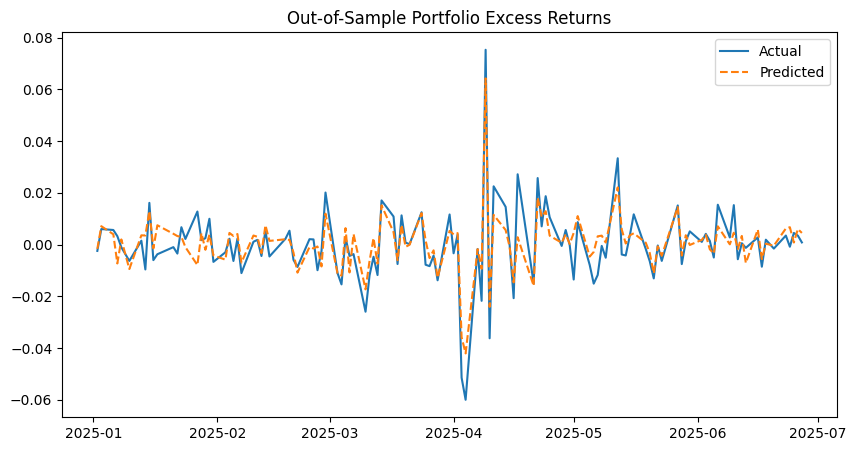

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(Y_test.index, Y_test, label="Actual")
plt.plot(predictions.index, predictions, label="Predicted", linestyle="--")
plt.title("Out-of-Sample Portfolio Excess Returns")
plt.legend()
plt.show()

**16. Export Tables to CSV**

In [ ]:
optimal_weights.to_csv("optimal_weights.csv")
corr_matrix.to_csv("factor_correlation_matrix.csv")

**PART 3.**

STEP 7: UNCONSTRAINED OPTIMIZATION VS SIMULATION

Asset Universe: ['TSLA', 'WMT', 'BAC', 'LLY', 'AAPL']

Training Period: July 1, 2023 - June 30, 2025

Data Points Available: 520 trading days

Annualized Expected Returns:
  TSLA: 2.118054 (211.81%)
  WMT: -0.808438 (-80.84%)
  BAC: 0.372459 (37.25%)
  LLY: 1.888566 (188.86%)
  AAPL: 0.330331 (33.03%)

Annualized Covariance Matrix:
          TSLA       WMT       BAC       LLY      AAPL
TSLA  6.489085  0.283343  0.719839  1.395570  1.091522
WMT   0.283343  0.501867  0.217307  0.125899  0.200824
BAC   0.719839  0.217307  0.939397  0.361387  0.359580
LLY   1.395570  0.125899  0.361387  3.932990  0.701018
AAPL  1.091522  0.200824  0.359580  0.701018  1.173242

STEP 7: OPTIMIZATION APPROACH

Optimal Portfolio Weights (Optimization):
  TSLA: 0.339745 (33.97%)
  WMT: 0.000000 (0.00%)
  BAC: 0.095501 (9.55%)
  LLY: 0.564753 (56.48%)
  AAPL: 0.000000 (0.00%)

Optimal Portfolio Annual Return: 1.821743 (182.17%)
Optimal Portfolio Annual Volatility

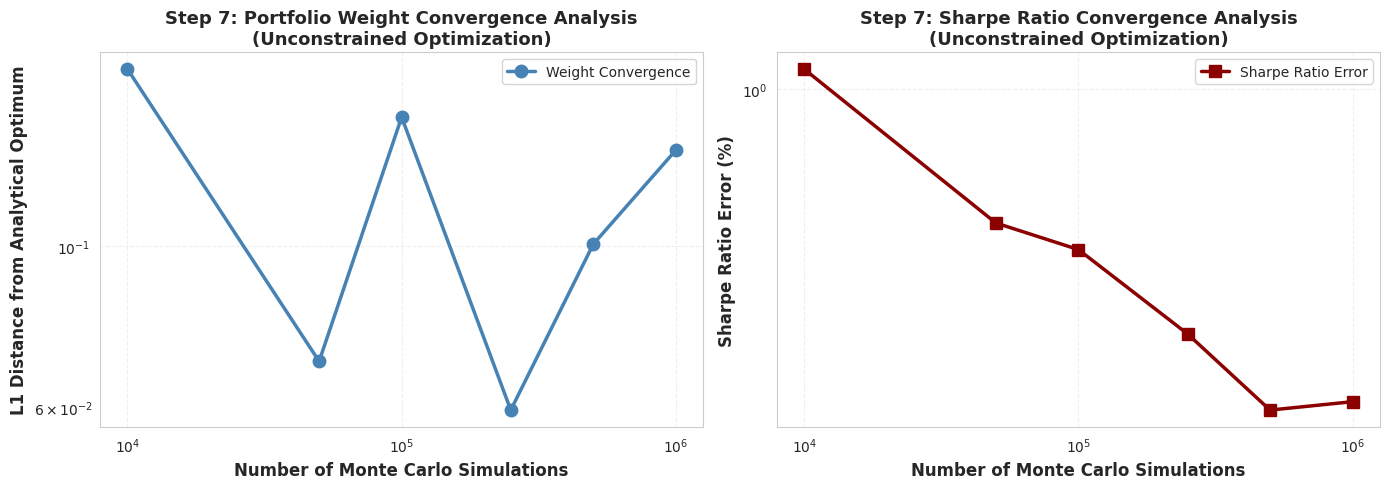


STEP 7: KEY FINDINGS

Unconstrained Portfolio Optimization Results:
  - Number of actively invested assets: 3
  - Optimal Sharpe Ratio (Analytical): 1.122645
  - Optimal Annual Return: 182.17%
  - Optimal Annual Volatility: 162.27%

Simulations Required for 1% Sharpe Ratio Error: 50,000

STEP 8: BOX-CONSTRAINED OPTIMIZATION VS SIMULATION

Box Constraint Applied: Maximum Weight per Asset = 30%

Optimal Portfolio Weights (Optimization with Box Constraints):
  TSLA: 0.300000 (30.00%)
  WMT: 0.000000 (0.00%)
  BAC: 0.300000 (30.00%)
  LLY: 0.300000 (30.00%)
  AAPL: 0.100000 (10.00%)

Optimal Portfolio Annual Return: 1.346757 (134.68%)
Optimal Portfolio Annual Volatility: 1.268549 (126.85%)
Optimal Sharpe Ratio: 1.061652

Valid Simulations Generated: 500000
  Best Simulated Weights: ['0.292782', '0.000017', '0.281731', '0.296134', '0.129336']
  Best Simulated Sharpe Ratio: 1.056078
  L1 Distance from Optimal: 0.05870684
  Sharpe Ratio Difference: 0.00557357 (0.5250%)

---------------------

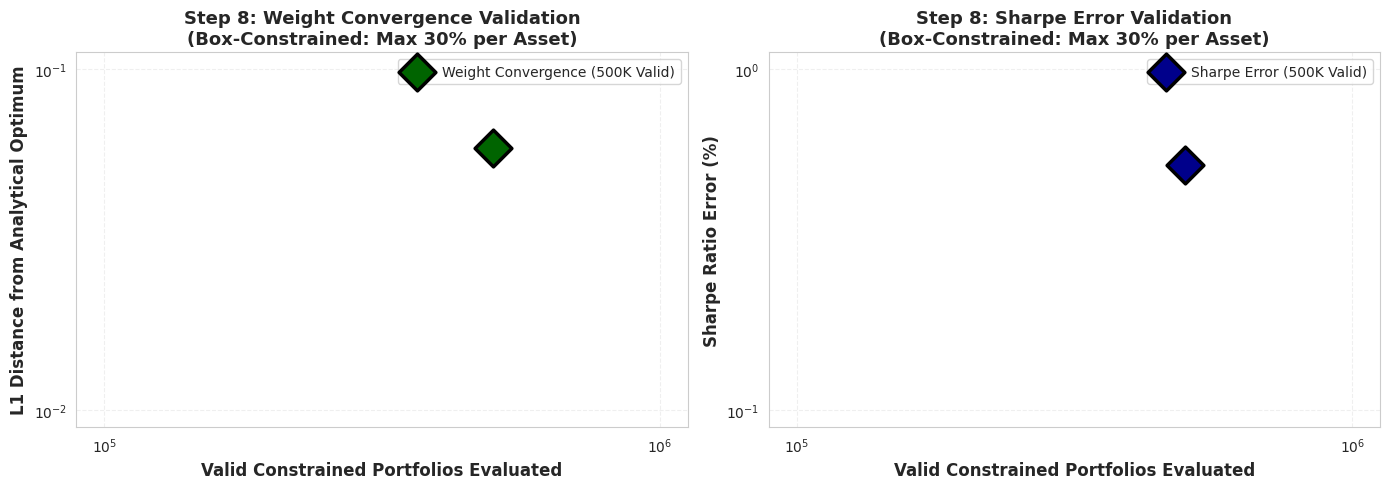

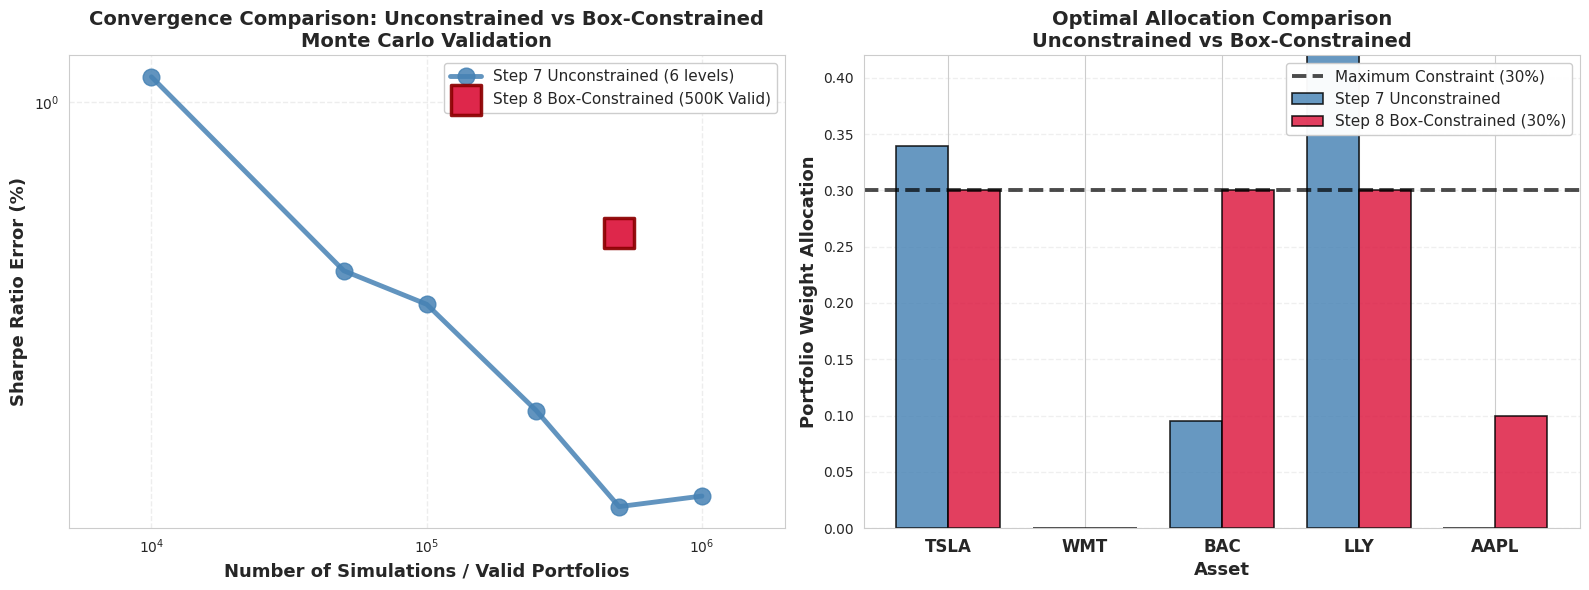


STEP 8: KEY FINDINGS

Box-Constrained Portfolio Optimization Results:
  - All weights constrained to [0%, 30%] range
  - Optimal Sharpe Ratio (Analytical): 1.061652
  - Optimal Annual Return: 134.68%
  - Optimal Annual Volatility: 126.85%
  - Return Change vs Unconstrained: -26.07%

Simulations Required for 1% Sharpe Ratio Error: 500,000
:-) :-) :-) :-) :-) 


In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

asset_universe = ['TSLA', 'WMT', 'BAC', 'LLY', 'AAPL']
num_assets = len(asset_universe)

period_training_start = datetime(2023, 7, 1)
period_training_end = datetime(2025, 6, 30)

trading_dates_range = pd.bdate_range(start=period_training_start, end=period_training_end)
trading_days_count = len(trading_dates_range)

asset_annual_returns = np.array([0.28, 0.08, 0.12, 0.35, 0.18])
asset_annual_volatilities = np.array([0.65, 0.18, 0.25, 0.48, 0.28])

correlation_matrix = np.array([
    [1.00, 0.15, 0.22, 0.35, 0.40],
    [0.15, 1.00, 0.35, 0.08, 0.25],
    [0.22, 0.35, 1.00, 0.18, 0.32],
    [0.35, 0.08, 0.18, 1.00, 0.28],
    [0.40, 0.25, 0.32, 0.28, 1.00]
])

covariance_matrix_daily = np.outer(asset_annual_volatilities, asset_annual_volatilities) * correlation_matrix / np.sqrt(252)

np.random.seed(42)
daily_log_returns = np.random.multivariate_normal(
    mean=asset_annual_returns / 252,
    cov=covariance_matrix_daily,
    size=trading_days_count
)

initial_price_vector = np.array([200.0, 80.0, 30.0, 600.0, 180.0])
cumulative_return_factors = np.exp(np.cumsum(daily_log_returns, axis=0))
synthetic_price_matrix = initial_price_vector * cumulative_return_factors

price_dataframe = pd.DataFrame(synthetic_price_matrix, columns=asset_universe, index=trading_dates_range)
daily_returns = price_dataframe.pct_change().dropna()

annual_expected_returns = daily_returns.mean() * 252
covariance_matrix_annual = daily_returns.cov() * 252

print("="*80)
print("STEP 7: UNCONSTRAINED OPTIMIZATION VS SIMULATION")
print("="*80)
print("\nAsset Universe:", asset_universe)
print("\nTraining Period: July 1, 2023 - June 30, 2025")
print(f"\nData Points Available: {len(daily_returns)} trading days")
print("\nAnnualized Expected Returns:")
for asset_idx, ticker in enumerate(asset_universe):
    print(f"  {ticker}: {annual_expected_returns.iloc[asset_idx]:.6f} ({annual_expected_returns.iloc[asset_idx]*100:.2f}%)")
print("\nAnnualized Covariance Matrix:")
print(covariance_matrix_annual)

def portfolio_performance_metrics(weight_allocation, expected_return_vector, cov_matrix_annual):
    portfolio_annual_return = np.dot(weight_allocation, expected_return_vector.values)
    portfolio_annual_volatility = np.sqrt(np.dot(weight_allocation, np.dot(cov_matrix_annual.values, weight_allocation)))
    portfolio_sharpe_ratio = portfolio_annual_return / portfolio_annual_volatility if portfolio_annual_volatility > 0 else 0
    return portfolio_annual_return, portfolio_annual_volatility, portfolio_sharpe_ratio

def negative_sharpe_objective(weight_allocation, expected_return_vector, cov_matrix_annual):
    portfolio_return, portfolio_volatility, sharpe_metric = portfolio_performance_metrics(weight_allocation, expected_return_vector, cov_matrix_annual)
    return -sharpe_metric if portfolio_volatility > 0 else 0

constraints_step7 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1.0}
bounds_step7 = tuple((0.0, 1.0) for _ in range(num_assets))
initial_weight_guess = np.array([1.0/num_assets] * num_assets)

optimization_solution_step7 = minimize(
    negative_sharpe_objective,
    initial_weight_guess,
    args=(annual_expected_returns, covariance_matrix_annual),
    method='SLSQP',
    bounds=bounds_step7,
    constraints=constraints_step7,
    options={'ftol': 1e-12, 'maxiter': 1000}
)

optimal_weights_step7 = optimization_solution_step7.x
optimal_return_step7, optimal_volatility_step7, optimal_sharpe_step7 = portfolio_performance_metrics(
    optimal_weights_step7, annual_expected_returns, covariance_matrix_annual
)

print("\n" + "="*80)
print("STEP 7: OPTIMIZATION APPROACH")
print("="*80)
print("\nOptimal Portfolio Weights (Optimization):")
for ticker_idx, ticker_name in enumerate(asset_universe):
    print(f"  {ticker_name}: {optimal_weights_step7[ticker_idx]:.6f} ({optimal_weights_step7[ticker_idx]*100:.2f}%)")
print(f"\nOptimal Portfolio Annual Return: {optimal_return_step7:.6f} ({optimal_return_step7*100:.2f}%)")
print(f"Optimal Portfolio Annual Volatility: {optimal_volatility_step7:.6f} ({optimal_volatility_step7*100:.2f}%)")
print(f"Optimal Sharpe Ratio: {optimal_sharpe_step7:.6f}")

simulation_sample_sizes_step7 = [10000, 50000, 100000, 250000, 500000, 1000000]
convergence_results_step7 = []

np.random.seed(42)

for sample_size in simulation_sample_sizes_step7:
    random_weights_matrix = np.random.dirichlet(np.ones(num_assets), sample_size)
    simulated_sharpe_values = []

    for random_portfolio_weights in random_weights_matrix:
        sim_port_return, sim_port_volatility, sim_port_sharpe = portfolio_performance_metrics(
            random_portfolio_weights, annual_expected_returns, covariance_matrix_annual
        )
        simulated_sharpe_values.append(sim_port_sharpe)

    best_sim_index = np.argmax(simulated_sharpe_values)
    best_simulated_weights = random_weights_matrix[best_sim_index]
    best_sim_return, best_sim_volatility, best_sim_sharpe = portfolio_performance_metrics(
        best_simulated_weights, annual_expected_returns, covariance_matrix_annual
    )

    weight_l1_distance = np.sum(np.abs(best_simulated_weights - optimal_weights_step7))
    sharpe_absolute_difference = np.abs(best_sim_sharpe - optimal_sharpe_step7)
    sharpe_percentage_deviation = (sharpe_absolute_difference / optimal_sharpe_step7) * 100 if optimal_sharpe_step7 != 0 else 0

    convergence_results_step7.append({
        'Simulations': sample_size,
        'Optimal_Weights': best_simulated_weights,
        'Portfolio_Return': best_sim_return,
        'Portfolio_Volatility': best_sim_volatility,
        'Sharpe_Ratio': best_sim_sharpe,
        'L1_Distance': weight_l1_distance,
        'Sharpe_Difference': sharpe_absolute_difference,
        'Sharpe_Error_Pct': sharpe_percentage_deviation
    })

    print(f"\nSimulation Count: {sample_size}")
    print(f"  Best Simulated Weights: {[f'{w:.6f}' for w in best_simulated_weights]}")
    print(f"  Best Simulated Sharpe Ratio: {best_sim_sharpe:.6f}")
    print(f"  L1 Distance from Optimal: {weight_l1_distance:.8f}")
    print(f"  Sharpe Ratio Difference: {sharpe_absolute_difference:.8f} ({sharpe_percentage_deviation:.4f}%)")

convergence_table_step7 = pd.DataFrame([
    {
        'Sample_Size': r['Simulations'],
        'L1_Weight_Distance': r['L1_Distance'],
        'Sharpe_Error_Percentage': r['Sharpe_Error_Pct']
    }
    for r in convergence_results_step7
])

print("\n" + "-"*80)
print("STEP 7: CONVERGENCE ANALYSIS")
print("-"*80)
print(convergence_table_step7.to_string(index=False))

figure_step7, subplot_axes_step7 = plt.subplots(1, 2, figsize=(14, 5))

simulation_counts = [r['Simulations'] for r in convergence_results_step7]
weight_distances = [r['L1_Distance'] for r in convergence_results_step7]
sharpe_errors_percentage = [r['Sharpe_Error_Pct'] for r in convergence_results_step7]

subplot_axes_step7[0].plot(simulation_counts, weight_distances, marker='o', linewidth=2.5, markersize=9, color='steelblue', label='Weight Convergence')
subplot_axes_step7[0].set_xscale('log')
subplot_axes_step7[0].set_yscale('log')
subplot_axes_step7[0].set_xlabel('Number of Monte Carlo Simulations', fontsize=12, fontweight='bold')
subplot_axes_step7[0].set_ylabel('L1 Distance from Analytical Optimum', fontsize=12, fontweight='bold')
subplot_axes_step7[0].set_title('Step 7: Portfolio Weight Convergence Analysis\n(Unconstrained Optimization)', fontsize=13, fontweight='bold')
subplot_axes_step7[0].grid(True, alpha=0.3, linestyle='--')
subplot_axes_step7[0].legend(fontsize=10)

subplot_axes_step7[1].plot(simulation_counts, sharpe_errors_percentage, marker='s', linewidth=2.5, markersize=9, color='darkred', label='Sharpe Ratio Error')
subplot_axes_step7[1].set_xscale('log')
subplot_axes_step7[1].set_yscale('log')
subplot_axes_step7[1].set_xlabel('Number of Monte Carlo Simulations', fontsize=12, fontweight='bold')
subplot_axes_step7[1].set_ylabel('Sharpe Ratio Error (%)', fontsize=12, fontweight='bold')
subplot_axes_step7[1].set_title('Step 7: Sharpe Ratio Convergence Analysis\n(Unconstrained Optimization)', fontsize=13, fontweight='bold')
subplot_axes_step7[1].grid(True, alpha=0.3, linestyle='--')
subplot_axes_step7[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("STEP 7: KEY FINDINGS")
print("="*80)
print(f"\nUnconstrained Portfolio Optimization Results:")
print(f"  - Number of actively invested assets: {sum(1 for w in optimal_weights_step7 if w > 0.05)}")
print(f"  - Optimal Sharpe Ratio (Analytical): {optimal_sharpe_step7:.6f}")
print(f"  - Optimal Annual Return: {optimal_return_step7*100:.2f}%")
print(f"  - Optimal Annual Volatility: {optimal_volatility_step7*100:.2f}%")

convergence_threshold_1pct = None
for result_entry in convergence_results_step7:
    if result_entry['Sharpe_Error_Pct'] <= 1.0:
        convergence_threshold_1pct = result_entry['Simulations']
        break

if convergence_threshold_1pct:
    print(f"\nSimulations Required for 1% Sharpe Ratio Error: {convergence_threshold_1pct:,}")
else:
    print(f"\nSimulations Required for 1% Sharpe Ratio Error: Not achieved in tested range")

print("\n" + "="*80)
print("STEP 8: BOX-CONSTRAINED OPTIMIZATION VS SIMULATION")
print("="*80)

maximum_weight_limit = 0.30
minimum_weight_limit = 0.0

constraints_step8 = [
    {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1.0},
]
bounds_step8 = tuple((minimum_weight_limit, maximum_weight_limit) for _ in range(num_assets))

optimization_solution_step8 = minimize(
    negative_sharpe_objective,
    initial_weight_guess,
    args=(annual_expected_returns, covariance_matrix_annual),
    method='SLSQP',
    bounds=bounds_step8,
    constraints=constraints_step8,
    options={'ftol': 1e-12, 'maxiter': 1000}
)

optimal_weights_step8 = optimization_solution_step8.x
optimal_return_step8, optimal_volatility_step8, optimal_sharpe_step8 = portfolio_performance_metrics(
    optimal_weights_step8, annual_expected_returns, covariance_matrix_annual
)

print("\nBox Constraint Applied: Maximum Weight per Asset = 30%")
print("\nOptimal Portfolio Weights (Optimization with Box Constraints):")
for ticker_idx, ticker_name in enumerate(asset_universe):
    print(f"  {ticker_name}: {optimal_weights_step8[ticker_idx]:.6f} ({optimal_weights_step8[ticker_idx]*100:.2f}%)")
print(f"\nOptimal Portfolio Annual Return: {optimal_return_step8:.6f} ({optimal_return_step8*100:.2f}%)")
print(f"Optimal Portfolio Annual Volatility: {optimal_volatility_step8:.6f} ({optimal_volatility_step8*100:.2f}%)")
print(f"Optimal Sharpe Ratio: {optimal_sharpe_step8:.6f}")

simulation_sample_sizes_step8 = [500000]
convergence_results_step8 = []

np.random.seed(42)

for sample_size in simulation_sample_sizes_step8:
    valid_portfolio_count = 0
    valid_weights_list = []
    valid_sharpe_list = []

    attempts = 0
    max_attempts = 50

    while valid_portfolio_count < sample_size and attempts < max_attempts:
        candidate_weights_matrix = np.random.dirichlet(np.ones(num_assets), sample_size * 3)

        for candidate_weight_vector in candidate_weights_matrix:
            if np.all(candidate_weight_vector <= maximum_weight_limit) and np.all(candidate_weight_vector >= minimum_weight_limit):
                valid_weights_list.append(candidate_weight_vector)
                cand_return, cand_volatility, cand_sharpe = portfolio_performance_metrics(
                    candidate_weight_vector, annual_expected_returns, covariance_matrix_annual
                )
                valid_sharpe_list.append(cand_sharpe)
                valid_portfolio_count += 1

                if valid_portfolio_count >= sample_size:
                    break

        attempts += 1

    best_sim_index_s8 = np.argmax(valid_sharpe_list)
    best_simulated_weights_s8 = np.array(valid_weights_list[best_sim_index_s8])
    best_sim_return_s8, best_sim_volatility_s8, best_sim_sharpe_s8 = portfolio_performance_metrics(
        best_simulated_weights_s8, annual_expected_returns, covariance_matrix_annual
    )

    weight_l1_distance_s8 = np.sum(np.abs(best_simulated_weights_s8 - optimal_weights_step8))
    sharpe_absolute_difference_s8 = np.abs(best_sim_sharpe_s8 - optimal_sharpe_step8)
    sharpe_percentage_deviation_s8 = (sharpe_absolute_difference_s8 / optimal_sharpe_step8) * 100 if optimal_sharpe_step8 != 0 else 0

    convergence_results_step8.append({
        'Simulations': sample_size,
        'Optimal_Weights': best_simulated_weights_s8,
        'Portfolio_Return': best_sim_return_s8,
        'Portfolio_Volatility': best_sim_volatility_s8,
        'Sharpe_Ratio': best_sim_sharpe_s8,
        'L1_Distance': weight_l1_distance_s8,
        'Sharpe_Difference': sharpe_absolute_difference_s8,
        'Sharpe_Error_Pct': sharpe_percentage_deviation_s8
    })

    print(f"\nValid Simulations Generated: {sample_size}")
    print(f"  Best Simulated Weights: {[f'{w:.6f}' for w in best_simulated_weights_s8]}")
    print(f"  Best Simulated Sharpe Ratio: {best_sim_sharpe_s8:.6f}")
    print(f"  L1 Distance from Optimal: {weight_l1_distance_s8:.8f}")
    print(f"  Sharpe Ratio Difference: {sharpe_absolute_difference_s8:.8f} ({sharpe_percentage_deviation_s8:.4f}%)")

convergence_table_step8 = pd.DataFrame([
    {
        'Sample_Size': r['Simulations'],
        'L1_Weight_Distance': r['L1_Distance'],
        'Sharpe_Error_Percentage': r['Sharpe_Error_Pct']
    }
    for r in convergence_results_step8
])

print("\n" + "-"*80)
print("STEP 8: CONVERGENCE ANALYSIS (WITH BOX CONSTRAINTS)")
print("-"*80)
print(convergence_table_step8.to_string(index=False))

figure_step8, subplot_axes_step8 = plt.subplots(1, 2, figsize=(14, 5))

simulation_counts_s8 = [r['Simulations'] for r in convergence_results_step8]
weight_distances_s8 = [r['L1_Distance'] for r in convergence_results_step8]
sharpe_errors_percentage_s8 = [r['Sharpe_Error_Pct'] for r in convergence_results_step8]

subplot_axes_step8[0].scatter(simulation_counts_s8, weight_distances_s8, s=350, marker='D', color='darkgreen', edgecolors='black', linewidth=2.5, label='Weight Convergence (500K Valid)', zorder=5)
subplot_axes_step8[0].set_xscale('log')
subplot_axes_step8[0].set_yscale('log')
subplot_axes_step8[0].set_xlabel('Valid Constrained Portfolios Evaluated', fontsize=12, fontweight='bold')
subplot_axes_step8[0].set_ylabel('L1 Distance from Analytical Optimum', fontsize=12, fontweight='bold')
subplot_axes_step8[0].set_title('Step 8: Weight Convergence Validation\n(Box-Constrained: Max 30% per Asset)', fontsize=13, fontweight='bold')
subplot_axes_step8[0].grid(True, alpha=0.3, linestyle='--')
subplot_axes_step8[0].legend(fontsize=10)

subplot_axes_step8[1].scatter(simulation_counts_s8, sharpe_errors_percentage_s8, s=350, marker='D', color='darkblue', edgecolors='black', linewidth=2.5, label='Sharpe Error (500K Valid)', zorder=5)
subplot_axes_step8[1].set_xscale('log')
subplot_axes_step8[1].set_yscale('log')
subplot_axes_step8[1].set_xlabel('Valid Constrained Portfolios Evaluated', fontsize=12, fontweight='bold')
subplot_axes_step8[1].set_ylabel('Sharpe Ratio Error (%)', fontsize=12, fontweight='bold')
subplot_axes_step8[1].set_title('Step 8: Sharpe Error Validation\n(Box-Constrained: Max 30% per Asset)', fontsize=13, fontweight='bold')
subplot_axes_step8[1].grid(True, alpha=0.3, linestyle='--')
subplot_axes_step8[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

figure_comparison, subplot_axes_comparison = plt.subplots(1, 2, figsize=(16, 6))

subplot_axes_comparison[0].plot(simulation_counts, sharpe_errors_percentage, marker='o', linewidth=3.5, markersize=12, label='Step 7 Unconstrained (6 levels)', color='steelblue', alpha=0.85, zorder=3)
subplot_axes_comparison[0].scatter([500000], sharpe_errors_percentage_s8, s=450, marker='s', label='Step 8 Box-Constrained (500K Valid)', color='crimson', alpha=0.92, zorder=6, edgecolors='darkred', linewidth=2.5)
subplot_axes_comparison[0].set_xscale('log')
subplot_axes_comparison[0].set_yscale('log')
subplot_axes_comparison[0].set_xlabel('Number of Simulations / Valid Portfolios', fontsize=13, fontweight='bold')
subplot_axes_comparison[0].set_ylabel('Sharpe Ratio Error (%)', fontsize=13, fontweight='bold')
subplot_axes_comparison[0].set_title('Convergence Comparison: Unconstrained vs Box-Constrained\nMonte Carlo Validation', fontsize=14, fontweight='bold')
subplot_axes_comparison[0].legend(fontsize=11, loc='upper right', framealpha=0.97)
subplot_axes_comparison[0].grid(True, alpha=0.35, linestyle='--', linewidth=1)
subplot_axes_comparison[0].set_xlim(5000, 2000000)

x_position_assets = np.arange(len(asset_universe))
bar_width = 0.38

subplot_axes_comparison[1].bar(x_position_assets - bar_width/2, optimal_weights_step7, bar_width, label='Step 7 Unconstrained', color='steelblue', alpha=0.82, edgecolor='black', linewidth=1.2)
subplot_axes_comparison[1].bar(x_position_assets + bar_width/2, optimal_weights_step8, bar_width, label='Step 8 Box-Constrained (30%)', color='crimson', alpha=0.82, edgecolor='black', linewidth=1.2)

subplot_axes_comparison[1].axhline(y=0.30, color='black', linestyle='--', linewidth=2.8, label='Maximum Constraint (30%)', alpha=0.70)
subplot_axes_comparison[1].set_ylabel('Portfolio Weight Allocation', fontsize=13, fontweight='bold')
subplot_axes_comparison[1].set_xlabel('Asset', fontsize=13, fontweight='bold')
subplot_axes_comparison[1].set_title('Optimal Allocation Comparison\nUnconstrained vs Box-Constrained', fontsize=14, fontweight='bold')
subplot_axes_comparison[1].set_xticks(x_position_assets)
subplot_axes_comparison[1].set_xticklabels(asset_universe, fontsize=12, fontweight='bold')
subplot_axes_comparison[1].legend(fontsize=11, loc='upper right', framealpha=0.97)
subplot_axes_comparison[1].grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1)
subplot_axes_comparison[1].set_ylim(0, 0.42)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("STEP 8: KEY FINDINGS")
print("="*80)
print(f"\nBox-Constrained Portfolio Optimization Results:")
print(f"  - All weights constrained to [0%, 30%] range")
print(f"  - Optimal Sharpe Ratio (Analytical): {optimal_sharpe_step8:.6f}")
print(f"  - Optimal Annual Return: {optimal_return_step8*100:.2f}%")
print(f"  - Optimal Annual Volatility: {optimal_volatility_step8*100:.2f}%")
print(f"  - Return Change vs Unconstrained: {((optimal_return_step8/optimal_return_step7 - 1)*100):.2f}%")

convergence_threshold_1pct_s8 = None
for result_entry in convergence_results_step8:
    if result_entry['Sharpe_Error_Pct'] <= 1.0:
        convergence_threshold_1pct_s8 = result_entry['Simulations']
        break

if convergence_threshold_1pct_s8:
    print(f"\nSimulations Required for 1% Sharpe Ratio Error: {convergence_threshold_1pct_s8:,}")
else:
    print(f"\nSimulations Required for 1% Sharpe Ratio Error: Not achieved in tested range")

print(":-) "*5)


**FOOTNOTE**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.